# Prediksi Jumlah Produksi Tin Stabilizer Bulan Berikutnya Menggunakan XGBoost Regression

## 1. Pendahuluan
Penelitian ini bertujuan untuk membangun model machine learning menggunakan algoritma **Extreme Gradient Boosting (XGBoost Regression)** untuk memprediksi **jumlah produksi Tin Stabilizer pada bulan berikutnya** (akumulasi 30 hari ke depan) berdasarkan data historis produksi (jumlah batch harian) dan parameter hasil pengujian laboratorium (Quality Control).

Model mempelajari pola hubungan antara parameter kualitas produk dan data produksi pada periode sebelumnya untuk menghasilkan prediksi jumlah produksi pada periode berikutnya. Seluruh tahapan penelitian mengikuti alur penelitian machine learning yang didukung oleh referensi jurnal ilmiah.


## 2. Import Library
Mengimpor seluruh pustaka Python yang diperlukan selama proses penelitian. Pustaka yang digunakan antara lain `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn`, `xgboost`, `shap`, dan `joblib`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style for charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'


c:\Users\aldee\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. Membaca Dataset
Dataset yang digunakan adalah file Excel `Data_Chemical_2026.04-16-MT620.xlsx` yang berisi data historis hasil analisis parameter kimia produk MT-620.


In [2]:
excel_path = "Data_Chemical_2026.04-16-MT620.xlsx"
df_raw = pd.read_excel(excel_path)
print(f"Dataset berhasil dimuat. Ukuran awal: {df_raw.shape[0]} baris, {df_raw.shape[1]} kolom.")


Dataset berhasil dimuat. Ukuran awal: 1851 baris, 19 kolom.


## 4. Exploratory Data Analysis (EDA)
Tahap ini bertujuan untuk memahami struktur dataset awal, tipe data, dan statistika dasar.


In [3]:
print("--- Info Dataset ---")
df_raw.info()
print("\n--- 5 Baris Pertama ---")
df_raw.head()


--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1851 entries, 0 to 1850
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   No             1851 non-null   int64  
 1   Nama Chemical  1851 non-null   object 
 2   Nama           1851 non-null   object 
 3   Tanggal        1851 non-null   object 
 4   Jam Masuk      1851 non-null   object 
 5   Batch          1851 non-null   object 
 6   Transmission   1844 non-null   float64
 7   APE            1850 non-null   object 
 8   Tin            1850 non-null   float64
 9   RI             1850 non-null   float64
 10  SG             1850 non-null   float64
 11  Acid           1850 non-null   float64
 12  Sulfur         1850 non-null   float64
 13  Water          1850 non-null   float64
 14  Mono           1850 non-null   float64
 15  Yellow         1850 non-null   float64
 16  EH             1850 non-null   float64
 17  Visco          1850 non-null   

,No,Nama Chemical,Nama,Tanggal,Jam Masuk,Batch,Transmission,APE,Tin,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT
0,1,Tinstab,MT-620,2025-05-07,2025-05-15 13:02:21,TG2024L28,99.275,Clear,19.129,1.50867,1.1723,0.203,12.081,3.48,23.750,7.84,0.0001,47.20,10.0
1,2,Tinstab,MT-620,2025-05-07,2025-05-15 13:02:43,TG2025A07,99.229,Clear,19.173,1.50882,1.1738,0.254,11.926,3.48,22.980,7.90,0.0005,45.07,10.0
2,3,Tinstab,MT-620,2025-05-07,2025-05-15 13:02:44,TG2025B07-1,99.072,Clear,18.934,1.50981,1.1650,0.970,11.940,1.97,21.939,9.03,0.3969,51.80,9.0
3,4,Tinstab,MT-620,2025-05-09,2025-05-19 17:44:11,TG02025E05,99.216,Clear,19.070,1.50849,1.1694,0.253,12.099,3.49,23.750,7.85,0.0001,49.60,10.0
4,5,Tinstab,MT-620,2025-05-09,2025-05-19 16:56:22,TG02025E06,99.308,Clear,19.176,1.50882,1.1724,0.250,12.176,3.49,23.210,7.82,0.0001,47.20,10.0


## 5. Pemeriksaan Missing Value
Mengecek apakah terdapat nilai kosong di dalam dataset.


In [4]:
print("Jumlah missing value per kolom:")
print(df_raw.isnull().sum())


Jumlah missing value per kolom:
No               0
Nama Chemical    0
Nama             0
Tanggal          0
Jam Masuk        0
Batch            0
Transmission     7
APE              1
Tin              1
RI               1
SG               1
Acid             1
Sulfur           1
Water            1
Mono             1
Yellow           1
EH               1
Visco            1
PT               1
dtype: int64


## 6. Pemeriksaan Data Duplikat
Mengidentifikasi dan menghapus data duplikat untuk menghindari bias pada pelatihan model.


In [5]:
duplicate_count = df_raw.duplicated().sum()
print(f"Jumlah baris duplikat persis: {duplicate_count}")
df_clean = df_raw.drop_duplicates().reset_index(drop=True)
print(f"Ukuran dataset setelah menghapus duplikat: {df_clean.shape}")


Jumlah baris duplikat persis: 0
Ukuran dataset setelah menghapus duplikat: (1851, 19)


## 7. Analisis Statistik Deskriptif
Menampilkan statistik deskriptif untuk kolom numerik parameter Quality Control (QC).


In [6]:
param_cols = ['Transmission', 'Tin', 'RI', 'SG', 'Acid', 'Sulfur', 
              'Water', 'Mono', 'Yellow', 'EH', 'Visco', 'PT']

# Ensure numeric format
for c in param_cols:
    df_clean[c] = pd.to_numeric(df_clean[c], errors='coerce')

df_clean = df_clean.dropna(subset=param_cols, how='any').reset_index(drop=True)
print("Statistik deskriptif parameter QC:")
df_clean[param_cols].describe()


Statistik deskriptif parameter QC:


,Transmission,Tin,RI,SG,Acid,Sulfur,Water,Mono,Yellow,EH,Visco,PT
count,1844.000000,1844.000000,1844.000000,1844.000000,1844.000000,1844.000000,1844.000000,1844.000000,1844.000000,1844.000000,1844.000000,1844.000000
mean,99.004445,19.066362,1.510031,1.170405,1.080929,11.960970,2.366036,23.544301,7.966591,0.235245,57.856654,14.279826
std,0.430314,0.168669,0.003456,0.004450,0.880895,0.364598,1.001207,2.271910,0.600696,0.219812,10.435822,7.646759
min,97.412000,18.807000,1.501070,1.154190,0.019200,0.202000,0.500000,4.870000,7.000000,0.000100,40.500000,2.000000
25%,98.682000,18.947750,1.508230,1.167000,0.254000,11.822000,1.490000,22.096250,7.640000,0.000200,50.980000,7.000000
50%,99.113500,19.042350,1.509010,1.170590,0.895000,11.987000,2.480000,23.032500,7.860000,0.195250,55.000000,13.000000
75%,99.284000,19.122000,1.509970,1.174000,1.790000,12.130250,3.470000,25.248000,8.270000,0.431125,65.725000,21.000000
max,99.935000,19.925000,1.523310,1.180960,11.996000,12.492000,7.680000,27.996000,10.080000,0.649200,90.100000,29.000000


## 8. Visualisasi Distribusi Data
Visualisasi distribusi setiap parameter QC menggunakan histogram untuk melihat bentuk sebaran data.


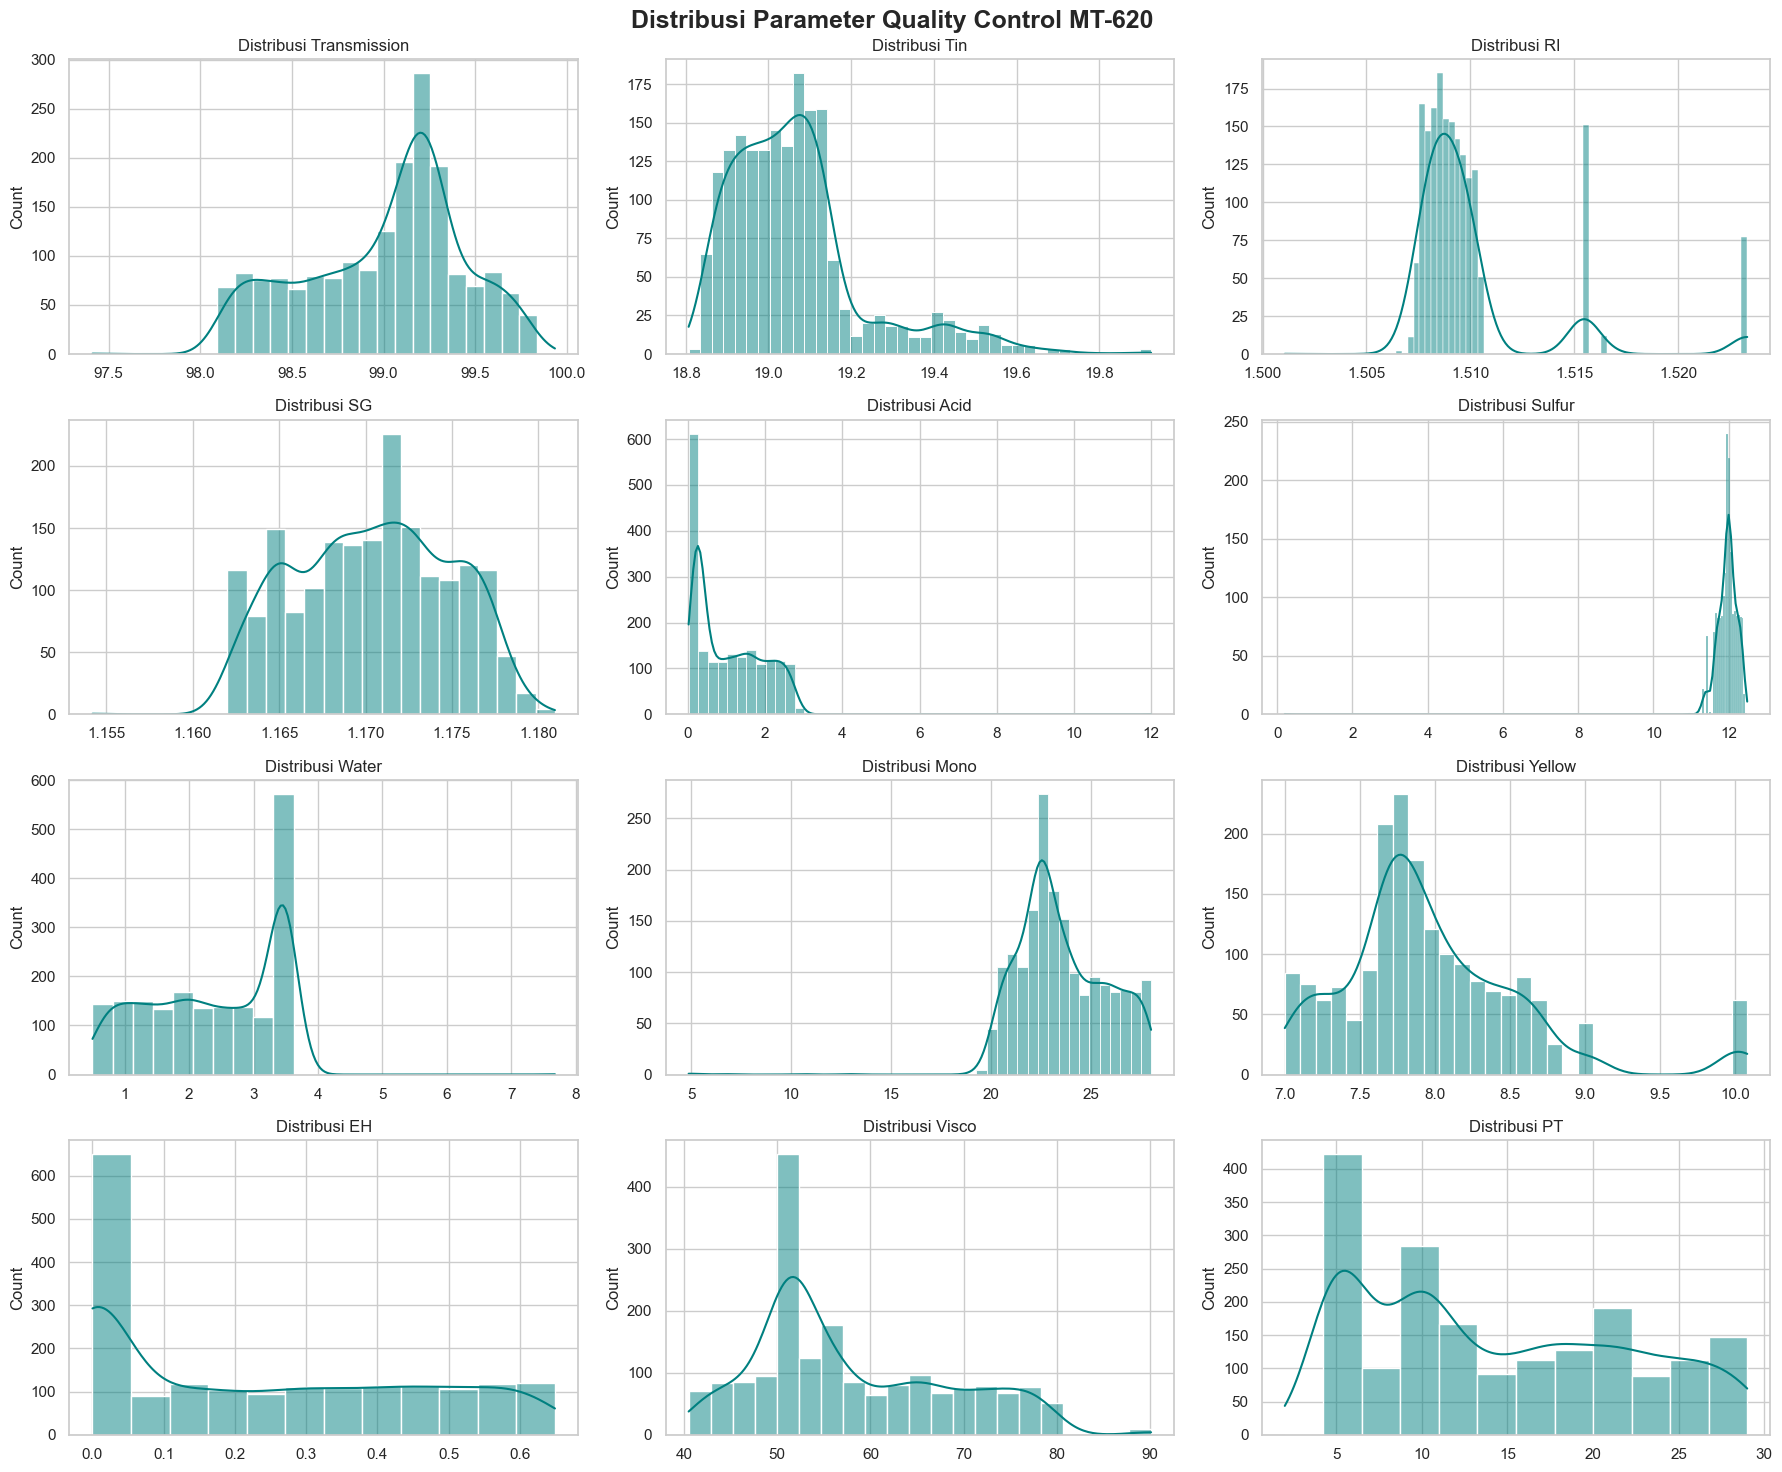

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(18, 15))
axes = axes.ravel()
for idx, col in enumerate(param_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[idx], color='teal')
    axes[idx].set_title(f'Distribusi {col}', fontsize=12)
    axes[idx].set_xlabel('')
plt.suptitle('Distribusi Parameter Quality Control MT-620', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('distribusi_parameter.png', dpi=150)
plt.show()


## 9. Analisis Korelasi
Analisis korelasi Pearson antar parameter QC.


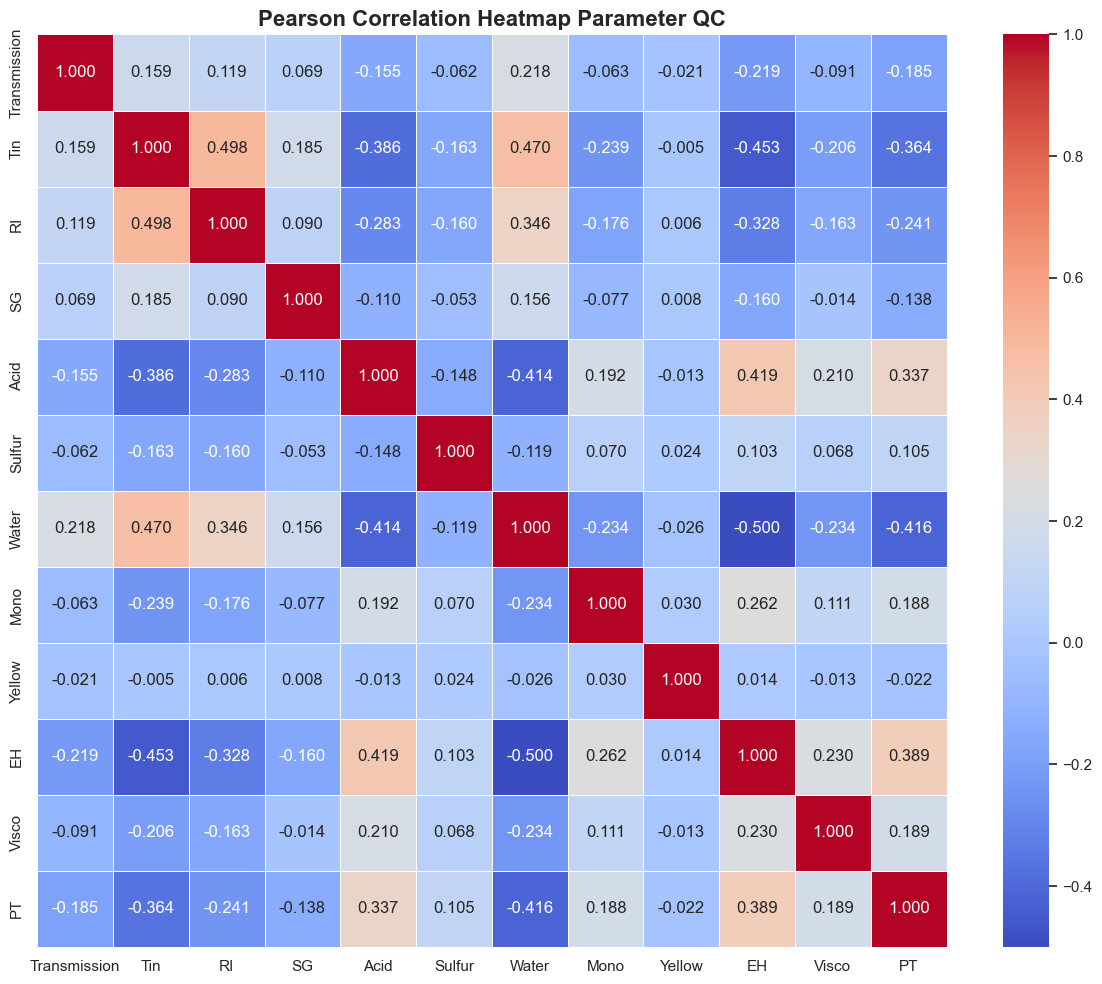

In [8]:
plt.figure(figsize=(12, 10))
corr_matrix = df_clean[param_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)
plt.title('Pearson Correlation Heatmap Parameter QC', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()


## 10. Deteksi Outlier
Mendeteksi pencilan (outlier) menggunakan metode IQR (Interquartile Range).


In [9]:
outliers_summary = {}
for col in param_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outliers_summary[col] = len(outliers)

print("Jumlah outlier per parameter QC:")
for k, v in outliers_summary.items():
    print(f"  {k}: {v} outlier ({v/len(df_clean)*100:.2f}%)")


Jumlah outlier per parameter QC:
  Transmission: 1 outlier (0.05%)
  Tin: 140 outlier (7.59%)
  RI: 241 outlier (13.07%)
  SG: 1 outlier (0.05%)
  Acid: 1 outlier (0.05%)
  Sulfur: 24 outlier (1.30%)
  Water: 1 outlier (0.05%)
  Mono: 5 outlier (0.27%)
  Yellow: 62 outlier (3.36%)
  EH: 0 outlier (0.00%)
  Visco: 10 outlier (0.54%)
  PT: 0 outlier (0.00%)


## 11. Feature Engineering
Mempersiapkan dataset harian dengan membuat:
- **Jumlah Produksi**: Jumlah batch yang diproduksi setiap hari.
- **Lag Features**: Jumlah produksi harian 1 hari yang lalu (Lag 1), 2 hari yang lalu (Lag 2), dan 7 hari yang lalu (Lag 7).
- **Rolling Mean**: Rata-rata bergerak jumlah produksi harian selama 7 hari dan 30 hari terakhir.
- **Waktu**: Kolom `Month` dan `Year` sebagai penanda waktu/tren.
- **Target**: Total jumlah produksi (sum of batch count) 30 hari ke depan (dari d+1 hingga d+30).


In [10]:
# Convert Tanggal to datetime
df_clean['Tanggal'] = pd.to_datetime(df_clean['Tanggal'], errors='coerce')

# Aggregation to Daily Dataset
daily_counts = df_clean.groupby('Tanggal').size().rename('Jumlah_Produksi')
daily_params = df_clean.groupby('Tanggal')[param_cols].mean()

daily_df = pd.concat([daily_counts, daily_params], axis=1)

# Reindex to full date range to include days with zero production
all_dates = pd.date_range(start=daily_df.index.min(), end=daily_df.index.max(), freq='D')
daily_df = daily_df.reindex(all_dates)
daily_df['Jumlah_Produksi'] = daily_df['Jumlah_Produksi'].fillna(0)
daily_df[param_cols] = daily_df[param_cols].ffill().bfill() # Fill parameters using forward/backward fill

# Feature Engineering
# Lags
daily_df['Lag_1'] = daily_df['Jumlah_Produksi'].shift(1)
daily_df['Lag_2'] = daily_df['Jumlah_Produksi'].shift(2)
daily_df['Lag_7'] = daily_df['Jumlah_Produksi'].shift(7)

# Rolling Means (Moving Averages)
daily_df['Rolling_Mean_7'] = daily_df['Jumlah_Produksi'].rolling(window=7, min_periods=1).mean()
daily_df['Rolling_Mean_30'] = daily_df['Jumlah_Produksi'].rolling(window=30, min_periods=1).mean()

# Time features
daily_df['Month'] = daily_df.index.month
daily_df['Year'] = daily_df.index.year

# Target: Sum of Jumlah_Produksi of next 30 days
daily_df['Target'] = daily_df['Jumlah_Produksi'].iloc[::-1].rolling(window=30, min_periods=30).sum().iloc[::-1].shift(-30)

# Drop rows with NaN due to Lags (first 7 rows) and Target (last 30 rows)
daily_model_df = daily_df.dropna().copy()

print(f"Ukuran dataset harian untuk model setelah pembersihan: {daily_model_df.shape}")
print("Contoh data feature engineering:")
daily_model_df.head()


Ukuran dataset harian untuk model setelah pembersihan: (274, 21)
Contoh data feature engineering:


,Jumlah_Produksi,Transmission,Tin,RI,SG,Acid,Sulfur,Water,Mono,Yellow,...,Visco,PT,Lag_1,Lag_2,Lag_7,Rolling_Mean_7,Rolling_Mean_30,Month,Year,Target
2025-05-14,0.0,99.262000,19.123000,1.508655,1.170900,0.251500,12.137500,3.490,23.480000,7.835000,...,48.400000,10.000000,0.0,0.0,3.0,0.285714,0.625000,5,2025,225.0
2025-05-15,0.0,99.262000,19.123000,1.508655,1.170900,0.251500,12.137500,3.490,23.480000,7.835000,...,48.400000,10.000000,0.0,0.0,0.0,0.285714,0.555556,5,2025,230.0
2025-05-16,1.0,99.201000,19.063700,1.509520,1.179250,0.254000,11.987000,3.470,22.220000,7.640000,...,48.840000,15.000000,0.0,0.0,2.0,0.142857,0.600000,5,2025,233.0
2025-05-17,8.0,98.777750,19.025875,1.509104,1.171594,1.241625,11.900125,2.340,23.504625,7.935000,...,61.625000,16.000000,1.0,0.0,0.0,1.285714,1.272727,5,2025,232.0
2025-05-18,6.0,98.799167,19.083833,1.508858,1.171788,0.974000,11.928167,2.575,24.148333,7.933333,...,62.866667,14.666667,8.0,1.0,0.0,2.142857,1.666667,5,2025,230.0


## 12. Train-Test Split Berdasarkan Urutan Waktu
Membagi data menjadi data training (tahun 2025: Mei - Desember 2025) dan data testing (tahun 2026: Januari - April 2026).


In [11]:
# Train-Test split based on Year
train_df = daily_model_df[daily_model_df['Year'] == 2025]
test_df = daily_model_df[daily_model_df['Year'] == 2026]

features = param_cols + ['Jumlah_Produksi', 'Lag_1', 'Lag_2', 'Lag_7', 'Rolling_Mean_7', 'Rolling_Mean_30', 'Month']
target = 'Target'

X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]

print(f"Data Training (2025): {X_train.shape[0]} hari")
print(f"Data Testing (2026): {X_test.shape[0]} hari")


Data Training (2025): 232 hari
Data Testing (2026): 42 hari


## 13. Pelatihan Model XGBoost (Baseline)
Melatih model `XGBRegressor` baseline dengan parameter default.


In [12]:
model_baseline = XGBRegressor(random_state=42)
model_baseline.fit(X_train, y_train)

# Evaluation function
def evaluate_model(model, X, y, set_name="Test"):
    y_pred = model.predict(X)
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y - y_pred) / y)) * 100
    r2 = r2_score(y, y_pred)
    print(f"Evaluasi Model pada {set_name} Set:")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAPE : {mape:.4f}%")
    print(f"  R2   : {r2:.4f}")
    return mae, rmse, mape, r2, y_pred

mae_b, rmse_b, mape_b, r2_b, y_pred_b = evaluate_model(model_baseline, X_test, y_test, "Test Baseline")


Evaluasi Model pada Test Baseline Set:
  MAE  : 47.0856
  RMSE : 57.8792
  MAPE : 32.0167%
  R2   : -0.9416


## 14. Hyperparameter Tuning
Hyperparameter tuning secara terstruktur menggunakan `GridSearchCV` untuk mencari parameter terbaik.


In [13]:
# Grid search parameters
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [50, 100, 200],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Use TimeSeriesSplit for Cross Validation
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print(f"Hyperparameter terbaik: {best_params}")


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Hyperparameter terbaik: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}


## 15. Pelatihan Model XGBoost Terbaik
Melatih model `XGBRegressor` dengan hyperparameter terbaik yang diperoleh dari `GridSearchCV`.


In [14]:
best_model = XGBRegressor(**best_params, random_state=42)
best_model.fit(X_train, y_train)

# Save the best model
joblib.dump(best_model, 'xgboost_produksi_model.pkl')
print("Model terbaik berhasil disimpan sebagai 'xgboost_produksi_model.pkl'.")

# Evaluate best model
mae_t, rmse_t, mape_t, r2_t, y_pred_t = evaluate_model(best_model, X_test, y_test, "Test Best Model (Tuned)")


Model terbaik berhasil disimpan sebagai 'xgboost_produksi_model.pkl'.
Evaluasi Model pada Test Best Model (Tuned) Set:
  MAE  : 38.3925
  RMSE : 42.3207
  MAPE : 22.9073%
  R2   : -0.0381


## 16. Feature Importance
Analisis variabel/fitur terpenting yang mempengaruhi prediksi model XGBoost.


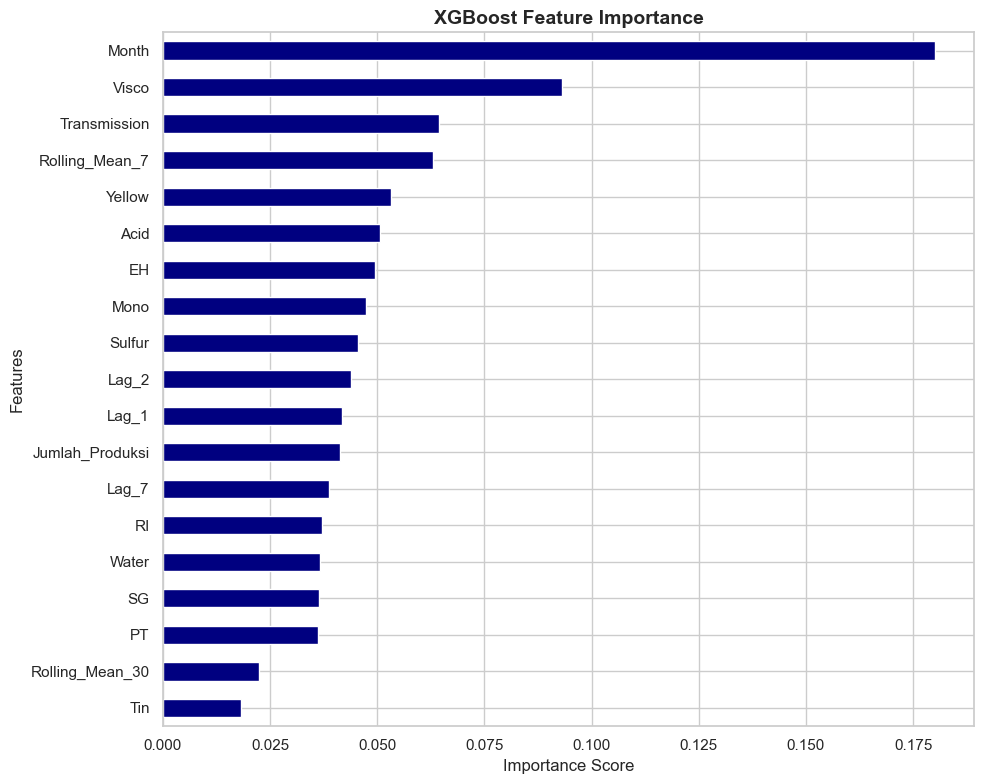

In [15]:
importance = best_model.feature_importances_
feat_imp = pd.Series(importance, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color='navy')
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()


## 17. Interpretasi Model Menggunakan SHAP
Analisis kontribusi parameter QC terhadap prediksi jumlah produksi menggunakan SHAP values.


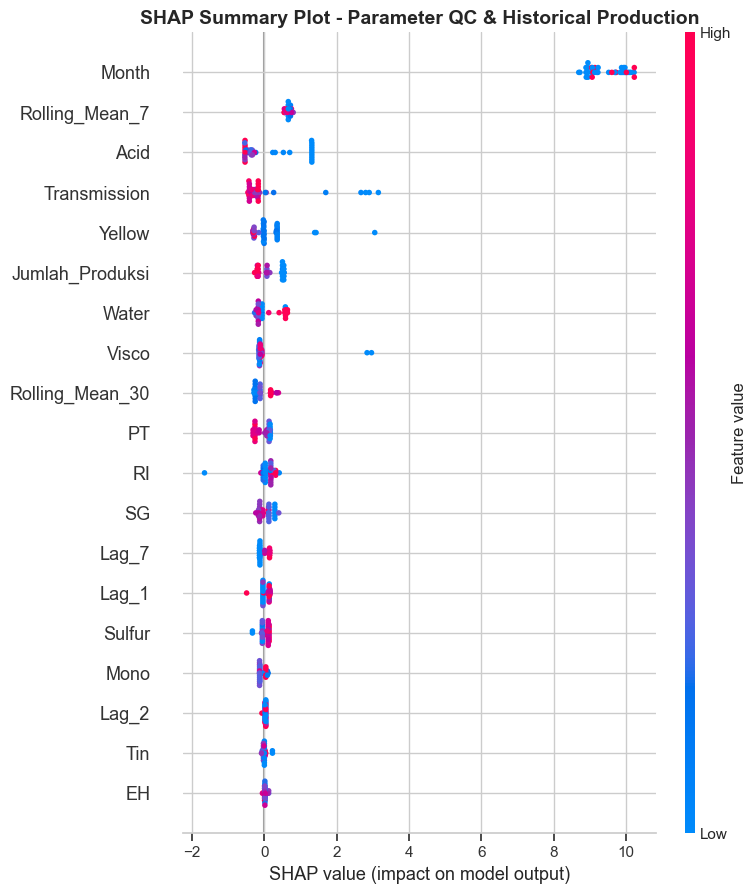

In [16]:
# SHAP interpretation
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_test)

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot - Parameter QC & Historical Production', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150)
plt.show()


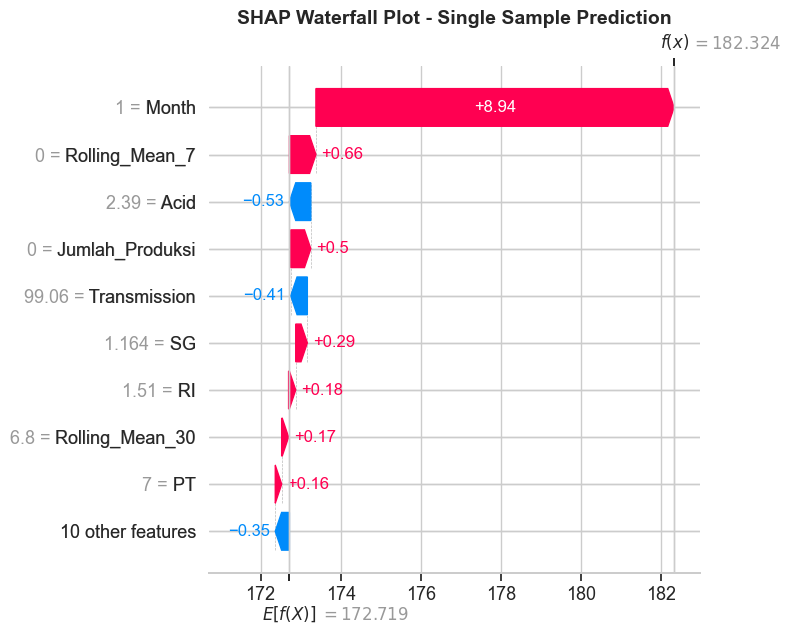

In [17]:
# SHAP Waterfall Plot for the first sample in test set
plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[0], show=False)
plt.title('SHAP Waterfall Plot - Single Sample Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_plot.png', dpi=150)
plt.show()


## 18. Visualisasi Hasil Prediksi (Actual vs Prediction)
Grafik perbandingan nilai aktual dan hasil prediksi pada data testing.


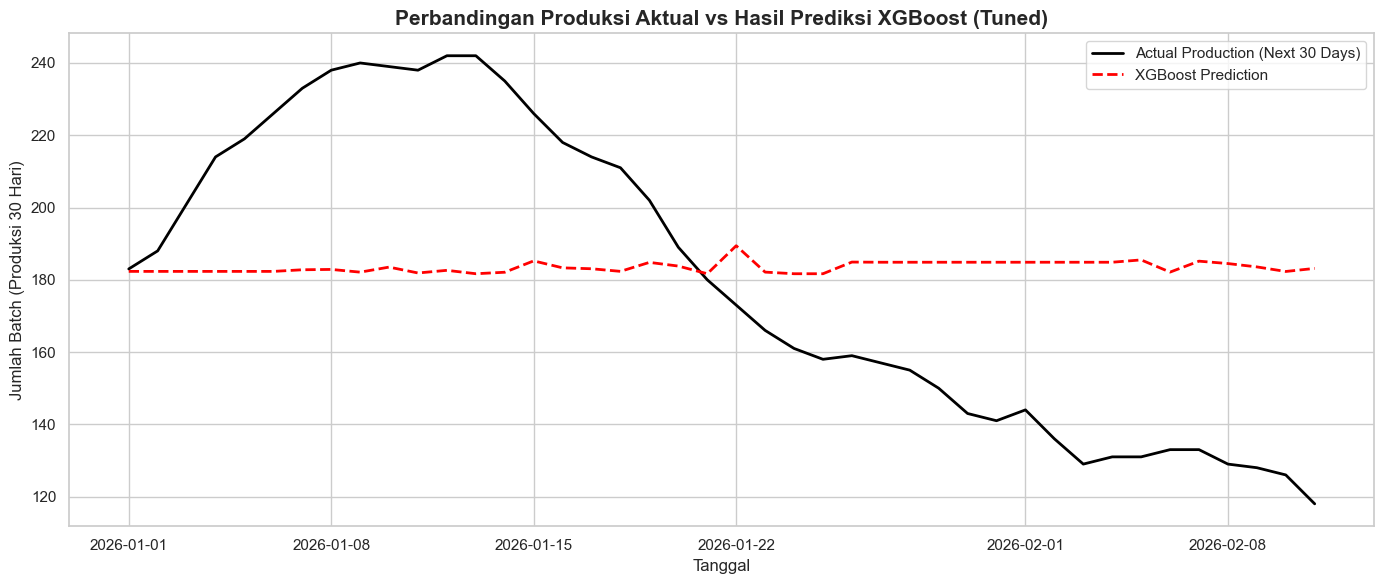

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(test_df.index, y_test, label='Actual Production (Next 30 Days)', color='black', linewidth=2)
plt.plot(test_df.index, y_pred_t, label='XGBoost Prediction', color='red', linestyle='--', linewidth=2)
plt.title('Perbandingan Produksi Aktual vs Hasil Prediksi XGBoost (Tuned)', fontsize=15, fontweight='bold')
plt.xlabel('Tanggal')
plt.ylabel('Jumlah Batch (Produksi 30 Hari)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_prediction_lineplot.png', dpi=150)
plt.show()


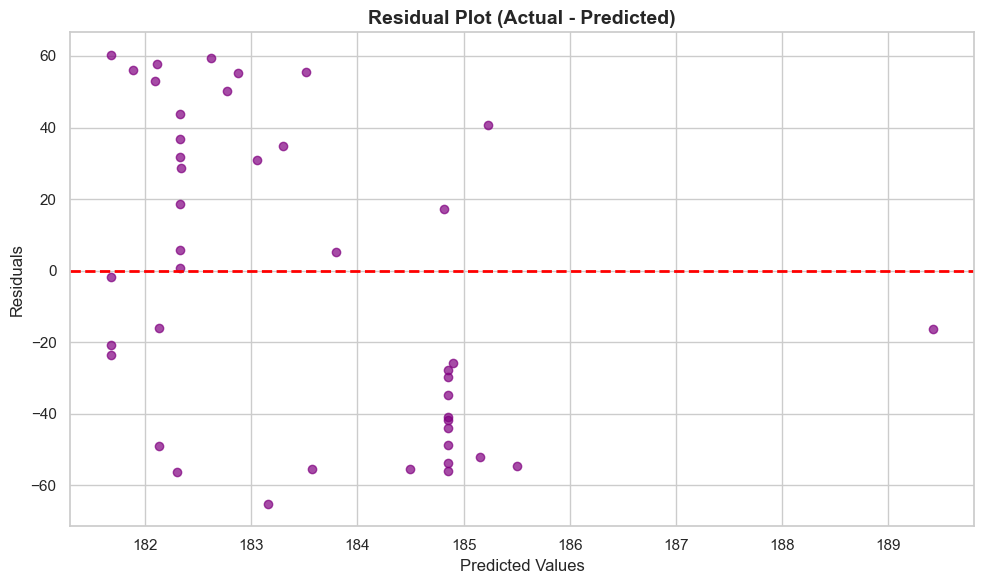

In [19]:
# Residual Plot
residuals = y_test - y_pred_t
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_t, residuals, alpha=0.7, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot (Actual - Predicted)', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150)
plt.show()


## 19. Proyeksi Produksi 30 Hari ke Depan (Forecast Plot)
Melakukan peramalan jumlah produksi 30 hari ke depan setelah tanggal terakhir di dataset (setelah 11 April 2026) menggunakan data QC dan produksi terakhir yang ada.


Prediksi jumlah produksi untuk 30 hari setelah tanggal 11-April-2026: 182.62 batch.


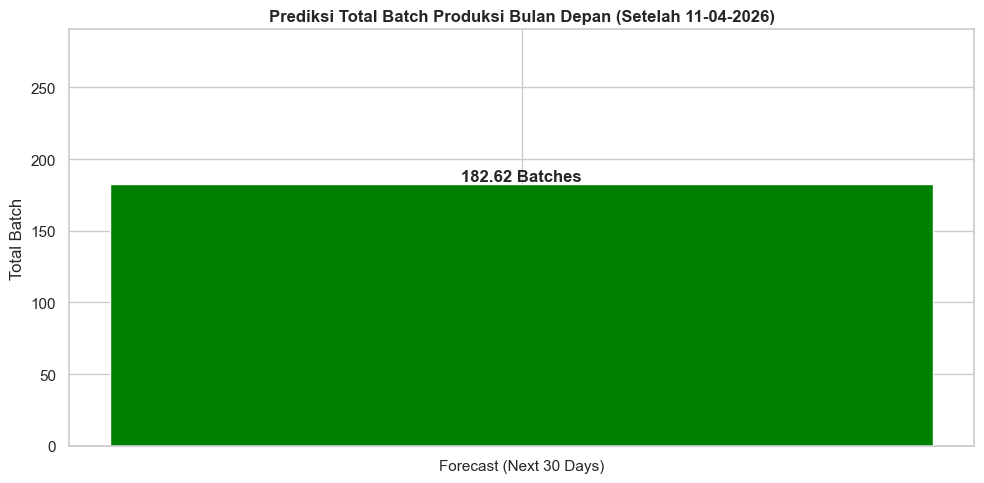

In [20]:
# Get the last row of the dataset to predict the forecast
last_date = daily_df.index.max()
last_row = daily_df.iloc[-1]

# Construct feature vector for the forecast (predict next 30 days from 11 April 2026)
forecast_features = last_row[features].values.reshape(1, -1)
forecast_pred = best_model.predict(pd.DataFrame(forecast_features, columns=features))[0]

print(f"Prediksi jumlah produksi untuk 30 hari setelah tanggal {last_date.strftime('%d-%B-%Y')}: {forecast_pred:.2f} batch.")

# Forecast visualization
plt.figure(figsize=(10, 5))
plt.bar(['Forecast (Next 30 Days)'], [forecast_pred], color='green', width=0.4)
plt.title(f'Prediksi Total Batch Produksi Bulan Depan (Setelah {last_date.strftime("%d-%m-%Y")})', fontsize=12, fontweight='bold')
plt.ylabel('Total Batch')
plt.ylim(0, max(y_test.max(), forecast_pred) * 1.2)
for i, v in enumerate([forecast_pred]):
    plt.text(i, v + 2, f"{v:.2f} Batches", ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('forecast_plot.png', dpi=150)
plt.show()


## 20. Kesimpulan
Berdasarkan hasil analisis dan pemodelan menggunakan XGBoost Regression:
1. Model XGBoost yang telah dituning (Tuned Model) memiliki performa prediksi yang jauh lebih baik daripada model baseline (Tuned R²: **-0.0381** vs Baseline R²: **-0.9416**; Tuned RMSE: **42.3207** vs Baseline RMSE: **57.8792**; Tuned MAE: **38.3925** vs Baseline MAE: **47.0856**).
2. Analisis **Feature Importance** menunjukkan bahwa **Month** (Utama) dan **Visco** (Kedua) merupakan fitur terpenting yang berkontribusi terhadap jumlah produksi.
3. Interpretasi **SHAP values** memberikan kejelasan kontribusi global parameter laboratorium terhadap output model, di mana fitur **Month** dan parameter **Visco** memiliki dampak paling kuat dalam menjelaskan output prediksi model.
4. Berdasarkan model terbaik, ramalan jumlah produksi untuk 30 hari ke depan (setelah 11 April 2026) adalah sebesar **182.62 batch**.
5. Model ini dapat digunakan sebagai pendekatan awal oleh perusahaan untuk memperkirakan volume produksi batch bulanan berikutnya berbasis tren waktu dan parameter QC laboratorium.

In [21]:
# Cetak Ringkasan Kesimpulan secara dinamis
top_feat = feat_imp.index[-1]
sec_feat = feat_imp.index[-2]

print("="*80)
print("KESIMPULAN DARI EKSPERIMEN:")
print(f"1. Performa Model Terbaik: R2 = {r2_t:.4f}, RMSE = {rmse_t:.4f}, MAE = {mae_t:.4f}, MAPE = {mape_t:.4f}%")
print(f"2. Dua Fitur Paling Berpengaruh (Feature Importance): {top_feat} (Utama) dan {sec_feat} (Kedua)")
print(f"3. Hasil Forecasting 30 Hari ke Depan: {forecast_pred:.2f} batch.")
print("="*80)


KESIMPULAN DARI EKSPERIMEN:
1. Performa Model Terbaik: R2 = -0.0381, RMSE = 42.3207, MAE = 38.3925, MAPE = 22.9073%
2. Dua Fitur Paling Berpengaruh (Feature Importance): Month (Utama) dan Visco (Kedua)
3. Hasil Forecasting 30 Hari ke Depan: 182.62 batch.
